# Digit Recognition Workshop 🔢

Welcome to this hands-on workshop on **Handwritten Digit Recognition** using Deep Learning!

## Workshop Overview

In this workshop, you will learn how to:
- Load and explore the famous MNIST dataset
- Preprocess image data for neural networks
- Build and train a neural network from scratch
- Evaluate model performance
- Make predictions on new data
- Visualize results and common errors

## What is Digit Recognition?

Digit recognition is a classic computer vision problem where we train a model to identify handwritten digits (0-9) from images. This is one of the fundamental problems in machine learning and serves as a great introduction to neural networks.

## The MNIST Dataset

MNIST (Modified National Institute of Standards and Technology) is a large database of handwritten digits commonly used for training image processing systems. It contains:
- **60,000 training images**
- **10,000 test images**
- Each image is **28x28 pixels** in grayscale

Let's get started! 🚀

## Step 1: Install and Import Required Libraries

Before we begin, make sure you have installed all dependencies. Run this command in your terminal:

```bash
pip install -r requirements.txt
```

Now, let's import all the libraries we'll need for this workshop:

- **TensorFlow/Keras**: For building and training neural networks
- **NumPy**: For numerical operations and array manipulations
- **Matplotlib**: For creating visualizations and plotting
- **Pandas**: For data manipulation and analysis
- **Seaborn**: For enhanced statistical visualizations

In [4]:
# Import core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import TensorFlow and Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten

# Import sklearn utilities
from sklearn.metrics import confusion_matrix, classification_report

# Set random seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

# Configure matplotlib
plt.style.use('default')
sns.set_palette("husl")

## Step 2: Load and Explore the MNIST Dataset

The MNIST dataset is conveniently included in Keras, so we can load it with a single line of code!

The dataset is already split into:
- **Training set**: Used to train our model
- **Test set**: Used to evaluate our model's performance on unseen data

Each image is a 28x28 pixel grayscale image, and each pixel value ranges from 0 (black) to 255 (white).

Let's load the data and examine its structure:

In [5]:
# Load the MNIST dataset
# This will download the dataset if it's not already cached locally
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Display dataset information
print("=" * 60)
print("MNIST DATASET INFORMATION")
print("=" * 60)
print(f"\nTraining set:")
print(f"  - Images shape: {X_train.shape}")
print(f"  - Labels shape: {y_train.shape}")
print(f"  - Number of training samples: {len(X_train)}")

print(f"\nTest set:")
print(f"  - Images shape: {X_test.shape}")
print(f"  - Labels shape: {y_test.shape}")
print(f"  - Number of test samples: {len(X_test)}")

print(f"\nImage properties:")
print(f"  - Image dimensions: 28x28 pixels")
print(f"  - Pixel value range: {X_train.min()} to {X_train.max()}")
print(f"  - Data type: {X_train.dtype}")

print(f"\nClasses (digits):")
print(f"  - Unique labels: {np.unique(y_train)}")
print(f"  - Number of classes: {len(np.unique(y_train))}")
print("=" * 60)

11490434/11490434 [==============================] - 1s 0us/step
MNIST DATASET INFORMATION

Training set:
  - Images shape: (60000, 28, 28)
  - Labels shape: (60000,)
  - Number of training samples: 60000

Test set:
  - Images shape: (10000, 28, 28)
  - Labels shape: (10000,)
  - Number of test samples: 10000

Image properties:
  - Image dimensions: 28x28 pixels
  - Pixel value range: 0 to 255
  - Data type: uint8

Classes (digits):
  - Unique labels: [0 1 2 3 4 5 6 7 8 9]
  - Number of classes: 10


## Step 3: Visualize Sample Digits

Let's visualize some sample digits from our training set to understand what we're working with.

This helps us:
- See the variety in handwriting styles
- Understand the quality of the images
- Verify the data loaded correctly
- Get familiar with the digit representations

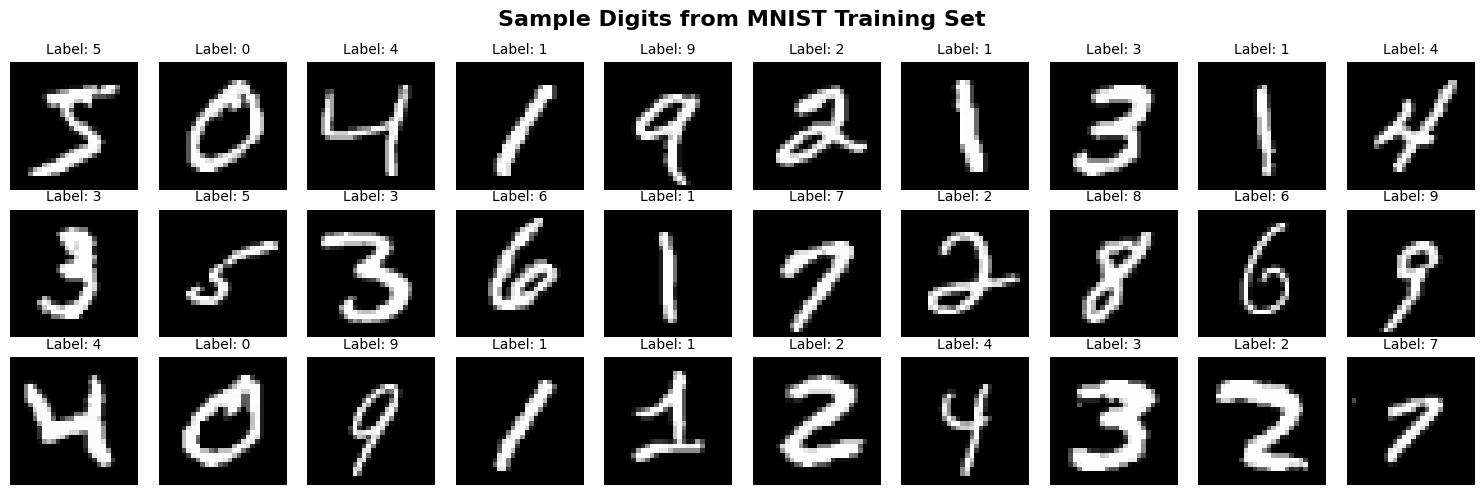

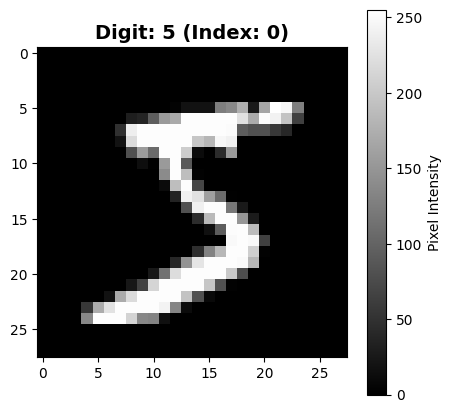

Sample digit shape: (28, 28)
Pixel values range from 0 to 255


In [6]:
# Create a grid of sample images
fig, axes = plt.subplots(3, 10, figsize=(15, 5))
fig.suptitle('Sample Digits from MNIST Training Set', fontsize=16, fontweight='bold')

for i in range(30):
    row = i // 10
    col = i % 10
    
    # Display the image
    axes[row, col].imshow(X_train[i], cmap='gray')
    axes[row, col].set_title(f'Label: {y_train[i]}', fontsize=10)
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Show a single digit in detail
plt.figure(figsize=(5, 5))
sample_idx = 0
plt.imshow(X_train[sample_idx], cmap='gray')
plt.title(f'Digit: {y_train[sample_idx]} (Index: {sample_idx})', fontsize=14, fontweight='bold')
plt.colorbar(label='Pixel Intensity')
plt.show()

print(f"Sample digit shape: {X_train[sample_idx].shape}")
print(f"Pixel values range from {X_train[sample_idx].min()} to {X_train[sample_idx].max()}")

## Step 4: Preprocess the Data

Before training our neural network, we need to preprocess the data:

### 1. **Normalization** 
   - Scale pixel values from [0, 255] to [0, 1]
   - Why? Neural networks perform better with smaller input values
   - Makes training faster and more stable

### 2. **Reshaping**
   - Flatten 28x28 images into 1D arrays of 784 values
   - Why? Our simple neural network expects 1D input

### 3. **One-Hot Encoding**
   - Convert labels (0-9) to binary vectors
   - Example: Label "3" becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
   - Why? This is the format our neural network's output layer expects

Let's apply these transformations:

In [7]:
# Store original shapes for later reference
original_train_shape = X_train.shape
original_test_shape = X_test.shape

# 1. Normalize pixel values from [0, 255] to [0, 1]
X_train_normalized = X_train.astype('float32') / 255.0
X_test_normalized = X_test.astype('float32') / 255.0

# 2. Reshape from (num_samples, 28, 28) to (num_samples, 784)
X_train_flattened = X_train_normalized.reshape(-1, 28 * 28)
X_test_flattened = X_test_normalized.reshape(-1, 28 * 28)

# 3. One-hot encode labels
# Example: 3 becomes [0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
num_classes = 10
y_train_encoded = to_categorical(y_train, num_classes)
y_test_encoded = to_categorical(y_test, num_classes)

# Display preprocessing results
print("=" * 60)
print("DATA PREPROCESSING SUMMARY")
print("=" * 60)

print("\n1. NORMALIZATION:")
print(f"   Original pixel range: [0, 255]")
print(f"   Normalized pixel range: [{X_train_normalized.min():.1f}, {X_train_normalized.max():.1f}]")

print("\n2. RESHAPING:")
print(f"   Original training shape: {original_train_shape}")
print(f"   Flattened training shape: {X_train_flattened.shape}")
print(f"   Original test shape: {original_test_shape}")
print(f"   Flattened test shape: {X_test_flattened.shape}")

print("\n3. ONE-HOT ENCODING:")
print(f"   Original label example: {y_train[0]}")
print(f"   Encoded label example: {y_train_encoded[0]}")
print(f"   Original labels shape: {y_train.shape}")
print(f"   Encoded labels shape: {y_train_encoded.shape}")

print("=" * 60)
print("✅ Data preprocessing complete!")
print("=" * 60)

DATA PREPROCESSING SUMMARY

1. NORMALIZATION:
   Original pixel range: [0, 255]
   Normalized pixel range: [0.0, 1.0]

2. RESHAPING:
   Original training shape: (60000, 28, 28)
   Flattened training shape: (60000, 784)
   Original test shape: (10000, 28, 28)
   Flattened test shape: (10000, 784)

3. ONE-HOT ENCODING:
   Original label example: 5
   Encoded label example: [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
   Original labels shape: (60000,)
   Encoded labels shape: (60000, 10)
✅ Data preprocessing complete!


## Step 5: Build a Neural Network Model

Now let's build our neural network! We'll create a **Sequential model** with multiple layers:

### Model Architecture:

1. **Input Layer**
   - Takes 784 input features (our flattened 28x28 image)
   
2. **Hidden Layer 1**
   - 128 neurons with ReLU activation
   - ReLU (Rectified Linear Unit) introduces non-linearity
   
3. **Dropout Layer 1**
   - Randomly drops 20% of connections during training
   - Helps prevent overfitting
   
4. **Hidden Layer 2**
   - 64 neurons with ReLU activation
   - Learns more complex patterns
   
5. **Dropout Layer 2**
   - Randomly drops 20% of connections
   
6. **Output Layer**
   - 10 neurons (one for each digit 0-9)
   - Softmax activation: converts outputs to probabilities
   - The neuron with highest probability is our prediction

Let's build it:

In [8]:
# Build the Sequential model
model = Sequential([
    # Input layer + First hidden layer
    Dense(128, activation='relu', input_shape=(784,), name='hidden_layer_1'),
    Dropout(0.2, name='dropout_1'),
    
    # Second hidden layer
    Dense(64, activation='relu', name='hidden_layer_2'),
    Dropout(0.2, name='dropout_2'),
    
    # Output layer
    Dense(10, activation='softmax', name='output_layer')
], name='digit_recognition_model')

# Display model architecture
print("=" * 60)
print("MODEL ARCHITECTURE")
print("=" * 60)
model.summary()
print("=" * 60)

# Calculate total parameters
total_params = model.count_params()
print(f"\n📊 Total trainable parameters: {total_params:,}")
print("✅ Model built successfully!")
print("=" * 60)

MODEL ARCHITECTURE
Model: "digit_recognition_model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 hidden_layer_1 (Dense)      (None, 128)               100480    
                                                                 
 dropout_1 (Dropout)         (None, 128)               0         
                                                                 
 hidden_layer_2 (Dense)      (None, 64)                8256      
                                                                 
 dropout_2 (Dropout)         (None, 64)                0         
                                                                 
 output_layer (Dense)        (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
__________________________________________________

## Step 6: Compile the Model

Before training, we need to **compile** the model by specifying:

### 1. **Optimizer: Adam**
   - Algorithm that adjusts the model's weights during training
   - Adam is an adaptive learning rate optimizer (efficient and widely used)
   - Learning rate determines how big the weight adjustments are

### 2. **Loss Function: Categorical Crossentropy**
   - Measures how wrong our predictions are
   - Specifically designed for multi-class classification
   - The model tries to minimize this loss during training

### 3. **Metrics: Accuracy**
   - Percentage of correct predictions
   - Easy to interpret: 95% accuracy means 95 out of 100 predictions are correct

Let's compile:

In [9]:
# Compile the model
model.compile(
    optimizer='adam',                      # Optimization algorithm
    loss='categorical_crossentropy',       # Loss function for multi-class classification
    metrics=['accuracy']                   # Track accuracy during training
)

print("=" * 60)
print("MODEL COMPILATION")
print("=" * 60)
print("\n✅ Model compiled successfully!")
print("\nConfiguration:")
print(f"  • Optimizer: Adam")
print(f"  • Loss Function: Categorical Crossentropy")
print(f"  • Metrics: Accuracy")
print("\n🚀 The model is now ready for training!")
print("=" * 60)

MODEL COMPILATION

✅ Model compiled successfully!

Configuration:
  • Optimizer: Adam
  • Loss Function: Categorical Crossentropy
  • Metrics: Accuracy

🚀 The model is now ready for training!


## Step 7: Train the Model

Now comes the exciting part - **training** our neural network! 🎯

### Training Parameters:

- **Epochs**: Number of times the model sees the entire dataset
  - We'll use 15 epochs
  - Each epoch improves the model's performance
  
- **Batch Size**: Number of samples processed before updating weights
  - We'll use 128 samples per batch
  - Smaller batches = more frequent updates, but slower
  - Larger batches = faster, but less frequent updates
  
- **Validation Split**: Percentage of training data used for validation
  - We'll use 10% (0.1) of training data for validation
  - Helps us monitor if the model is overfitting

### What to Watch During Training:

- **loss**: How wrong the model is (lower is better)
- **accuracy**: Percentage of correct predictions (higher is better)
- **val_loss & val_accuracy**: Same metrics on unseen validation data

Let's train! ⏱️ This may take a few minutes...

In [10]:
# Train the model
print("🚀 Starting training...\n")

history = model.fit(
    X_train_flattened,           # Training data
    y_train_encoded,             # Training labels
    epochs=15,                   # Number of complete passes through the dataset
    batch_size=128,              # Number of samples per gradient update
    validation_split=0.1,        # Use 10% of training data for validation
    verbose=1                    # Show progress bar
)

print("\n" + "=" * 60)
print("🎉 TRAINING COMPLETE!")
print("=" * 60)

# Display final training results
final_train_loss = history.history['loss'][-1]
final_train_acc = history.history['accuracy'][-1]
final_val_loss = history.history['val_loss'][-1]
final_val_acc = history.history['val_accuracy'][-1]

print(f"\nFinal Training Results:")
print(f"  • Training Loss: {final_train_loss:.4f}")
print(f"  • Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"  • Validation Loss: {final_val_loss:.4f}")
print(f"  • Validation Accuracy: {final_val_acc * 100:.2f}%")
print("=" * 60)

🚀 Starting training...

Epoch 1/15
422/422 [==============================] - 0s 891us/step - loss: 0.4751 - accuracy: 0.8567 - val_loss: 0.1447 - val_accuracy: 0.9573
Epoch 2/15
422/422 [==============================] - 0s 777us/step - loss: 0.2102 - accuracy: 0.9370 - val_loss: 0.1028 - val_accuracy: 0.9707
Epoch 3/15
422/422 [==============================] - 0s 774us/step - loss: 0.1562 - accuracy: 0.9536 - val_loss: 0.0907 - val_accuracy: 0.9737
Epoch 4/15
422/422 [==============================] - 0s 765us/step - loss: 0.1288 - accuracy: 0.9604 - val_loss: 0.0778 - val_accuracy: 0.9777
Epoch 5/15
422/422 [==============================] - 0s 767us/step - loss: 0.1128 - accuracy: 0.9652 - val_loss: 0.0766 - val_accuracy: 0.9785
Epoch 6/15
422/422 [==============================] - 0s 773us/step - loss: 0.0980 - accuracy: 0.9696 - val_loss: 0.0710 - val_accuracy: 0.9773
Epoch 7/15
422/422 [==============================] - 0s 765us/step - loss: 0.0903 - accuracy: 0.9719 - val_loss

## Step 8: Evaluate Model Performance

Now let's test our model on completely unseen data - the **test set**!

This is the most important evaluation because:
- The model has never seen this data during training
- It shows how well the model generalizes to new examples
- It's the true measure of our model's performance

We'll calculate:
- **Test Loss**: How wrong the model is on test data
- **Test Accuracy**: Percentage of correct predictions on test data

Let's see how well our model performs:

In [11]:
# Evaluate the model on test data
print("🧪 Evaluating model on test data...\n")

test_loss, test_accuracy = model.evaluate(X_test_flattened, y_test_encoded, verbose=0)

print("=" * 60)
print("📊 TEST SET PERFORMANCE")
print("=" * 60)
print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"\nThis means our model correctly predicts {test_accuracy * 100:.2f}% of digits!")
print(f"Out of {len(X_test)} test images, approximately {int(test_accuracy * len(X_test))} are correct.")

# Compare with training performance
print("\n" + "-" * 60)
print("COMPARISON: Training vs Test Performance")
print("-" * 60)
print(f"Training Accuracy: {final_train_acc * 100:.2f}%")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Difference: {abs(final_train_acc - test_accuracy) * 100:.2f}%")

if abs(final_train_acc - test_accuracy) < 0.05:
    print("\n✅ Great! The model generalizes well (low overfitting).")
elif abs(final_train_acc - test_accuracy) < 0.10:
    print("\n⚠️ Some overfitting detected, but performance is still good.")
else:
    print("\n❌ Significant overfitting - model may need regularization.")
    
print("=" * 60)

🧪 Evaluating model on test data...

📊 TEST SET PERFORMANCE

Test Loss: 0.0748
Test Accuracy: 97.86%

This means our model correctly predicts 97.86% of digits!
Out of 10000 test images, approximately 9786 are correct.

------------------------------------------------------------
COMPARISON: Training vs Test Performance
------------------------------------------------------------
Training Accuracy: 98.40%
Test Accuracy: 97.86%
Difference: 0.54%

✅ Great! The model generalizes well (low overfitting).


## Step 9: Visualize Training History

Let's visualize how our model learned over time! 📈

These plots help us understand:
- **How quickly the model learned** (steep curves = fast learning)
- **If the model is overfitting** (training accuracy >> validation accuracy)
- **If we trained for enough epochs** (curves still improving = train longer)
- **If the model is underfitting** (both accuracies are low)

We'll create two plots:
1. **Accuracy over epochs**: Shows learning progress
2. **Loss over epochs**: Shows how the error decreased

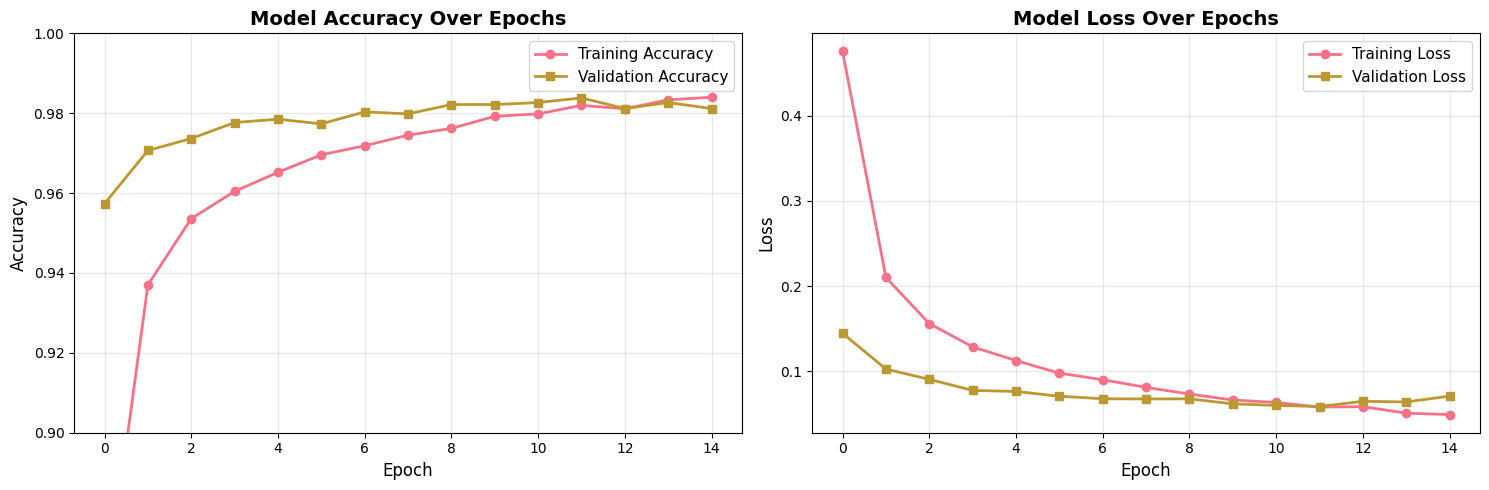

📊 Training Insights:
------------------------------------------------------------
✅ Excellent performance! Validation accuracy is very high.
✅ Good generalization! Training and validation curves are close.
------------------------------------------------------------


In [12]:
# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Accuracy over epochs
ax1.plot(history.history['accuracy'], label='Training Accuracy', marker='o', linewidth=2)
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='s', linewidth=2)
ax1.set_title('Model Accuracy Over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.set_ylim([0.9, 1.0])

# Plot 2: Loss over epochs
ax2.plot(history.history['loss'], label='Training Loss', marker='o', linewidth=2)
ax2.plot(history.history['val_loss'], label='Validation Loss', marker='s', linewidth=2)
ax2.set_title('Model Loss Over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print insights
print("📊 Training Insights:")
print("-" * 60)
if history.history['val_accuracy'][-1] >= 0.97:
    print("✅ Excellent performance! Validation accuracy is very high.")
else:
    print("⚠️ Model could be improved. Try more epochs or different architecture.")
    
if abs(history.history['accuracy'][-1] - history.history['val_accuracy'][-1]) < 0.05:
    print("✅ Good generalization! Training and validation curves are close.")
else:
    print("⚠️ Some overfitting detected. Consider more dropout or regularization.")
print("-" * 60)

## Step 10: Make Predictions on Test Data

Let's use our trained model to make predictions! 🔮

### How Predictions Work:

1. The model takes an image as input (784 pixel values)
2. It processes the image through all layers
3. The output layer produces 10 probability values (one for each digit 0-9)
4. The digit with the highest probability is the prediction

For example:
- Output: [0.01, 0.02, 0.05, 0.85, 0.02, 0.01, 0.01, 0.02, 0.01, 0.00]
- Highest probability: 0.85 at index 3
- **Prediction: 3**

Let's see our model in action:

🔮 Making predictions on test data...

PREDICTION EXAMPLES

Sample 1:
  True Label: 7
  Predicted: 7
  Confidence: 100.00%
  Correct: ✅

Sample 2:
  True Label: 2
  Predicted: 2
  Confidence: 100.00%
  Correct: ✅

Sample 3:
  True Label: 1
  Predicted: 1
  Confidence: 100.00%
  Correct: ✅

Sample 4:
  True Label: 0
  Predicted: 0
  Confidence: 100.00%
  Correct: ✅

Sample 5:
  True Label: 4
  Predicted: 4
  Confidence: 99.22%
  Correct: ✅

Sample 6:
  True Label: 1
  Predicted: 1
  Confidence: 100.00%
  Correct: ✅

Sample 7:
  True Label: 4
  Predicted: 4
  Confidence: 99.86%
  Correct: ✅

Sample 8:
  True Label: 9
  Predicted: 9
  Confidence: 99.56%
  Correct: ✅

Sample 9:
  True Label: 5
  Predicted: 6
  Confidence: 83.95%
  Correct: ❌

Sample 10:
  True Label: 9
  Predicted: 9
  Confidence: 99.31%
  Correct: ✅



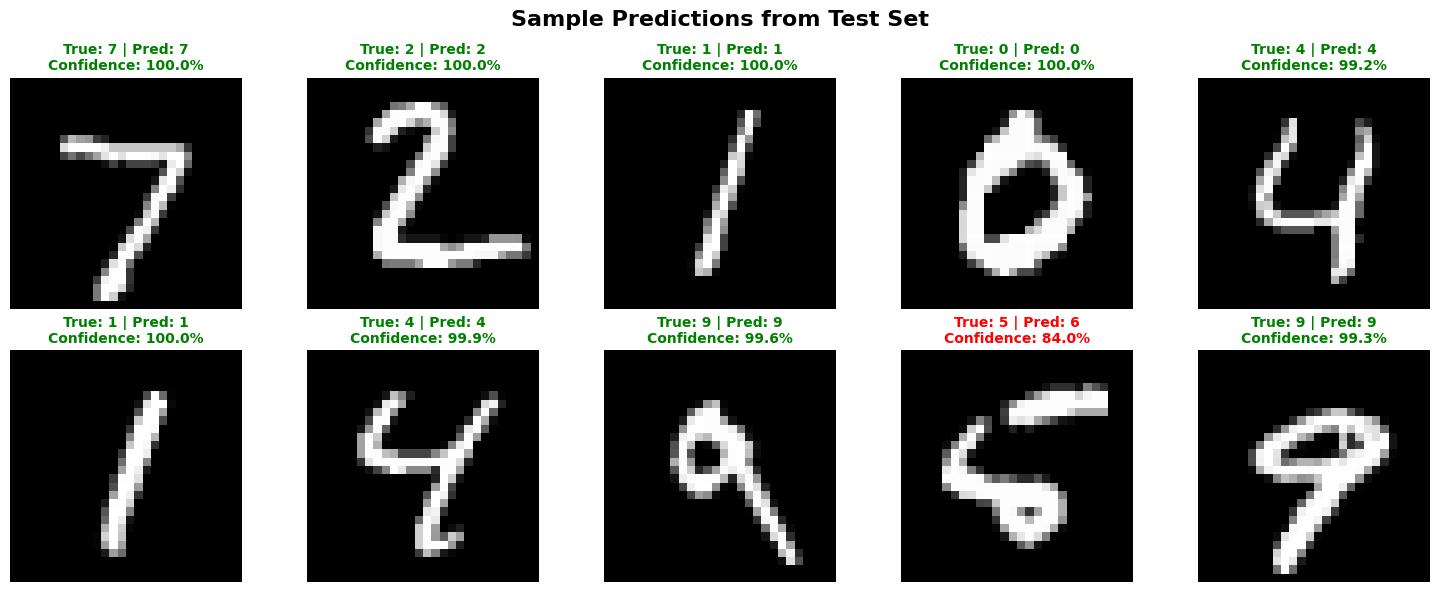


📊 Overall Statistics:
  Total predictions: 10000
  Correct predictions: 9786
  Incorrect predictions: 214
  Accuracy: 97.86%


In [13]:
# Make predictions on test data
print("🔮 Making predictions on test data...\n")
predictions = model.predict(X_test_flattened, verbose=0)

# Convert predictions from probabilities to class labels
predicted_classes = np.argmax(predictions, axis=1)

print("=" * 60)
print("PREDICTION EXAMPLES")
print("=" * 60)

# Show first 10 predictions
for i in range(10):
    print(f"\nSample {i + 1}:")
    print(f"  True Label: {y_test[i]}")
    print(f"  Predicted: {predicted_classes[i]}")
    print(f"  Confidence: {predictions[i][predicted_classes[i]] * 100:.2f}%")
    print(f"  Correct: {'✅' if predicted_classes[i] == y_test[i] else '❌'}")

print("\n" + "=" * 60)

# Visualize some predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Sample Predictions from Test Set', fontsize=16, fontweight='bold')

for i in range(10):
    row = i // 5
    col = i % 5
    
    # Display image
    axes[row, col].imshow(X_test[i], cmap='gray')
    
    # Color code: green for correct, red for incorrect
    is_correct = predicted_classes[i] == y_test[i]
    color = 'green' if is_correct else 'red'
    
    # Title with true and predicted labels
    title = f"True: {y_test[i]} | Pred: {predicted_classes[i]}\n"
    title += f"Confidence: {predictions[i][predicted_classes[i]] * 100:.1f}%"
    axes[row, col].set_title(title, fontsize=10, color=color, fontweight='bold')
    axes[row, col].axis('off')

plt.tight_layout()
plt.show()

# Calculate overall statistics
correct_predictions = np.sum(predicted_classes == y_test)
total_predictions = len(y_test)

print(f"\n📊 Overall Statistics:")
print(f"  Total predictions: {total_predictions}")
print(f"  Correct predictions: {correct_predictions}")
print(f"  Incorrect predictions: {total_predictions - correct_predictions}")
print(f"  Accuracy: {correct_predictions / total_predictions * 100:.2f}%")

## Step 11: Visualize Predictions and Errors

Understanding where our model makes mistakes is crucial for improvement! 🔍

### What We'll Analyze:

1. **Confusion Matrix**: Shows which digits are confused with each other
2. **Error Examples**: Visualize the digits that were misclassified
3. **Classification Report**: Detailed metrics for each digit class

This helps us understand:
- Which digits are hardest to recognize?
- Which digits look similar and get confused?
- Are some digits predicted better than others?

Let's dive in:

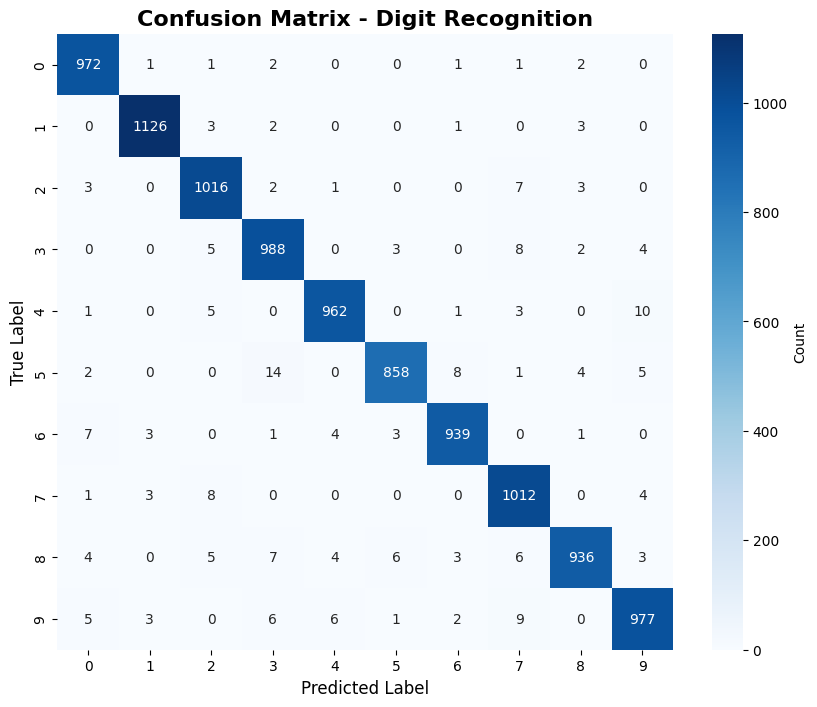

📊 How to read the Confusion Matrix:
------------------------------------------------------------
• Rows represent TRUE labels
• Columns represent PREDICTED labels
• Diagonal (top-left to bottom-right) = Correct predictions
• Off-diagonal values = Misclassifications
• Darker blue = More occurrences
------------------------------------------------------------

📈 DETAILED CLASSIFICATION REPORT
              precision    recall  f1-score   support

     Digit 0     0.9769    0.9918    0.9843       980
     Digit 1     0.9912    0.9921    0.9916      1135
     Digit 2     0.9741    0.9845    0.9793      1032
     Digit 3     0.9667    0.9782    0.9724      1010
     Digit 4     0.9846    0.9796    0.9821       982
     Digit 5     0.9851    0.9619    0.9733       892
     Digit 6     0.9832    0.9802    0.9817       958
     Digit 7     0.9666    0.9844    0.9754      1028
     Digit 8     0.9842    0.9610    0.9725       974
     Digit 9     0.9741    0.9683    0.9712      1009

    accura

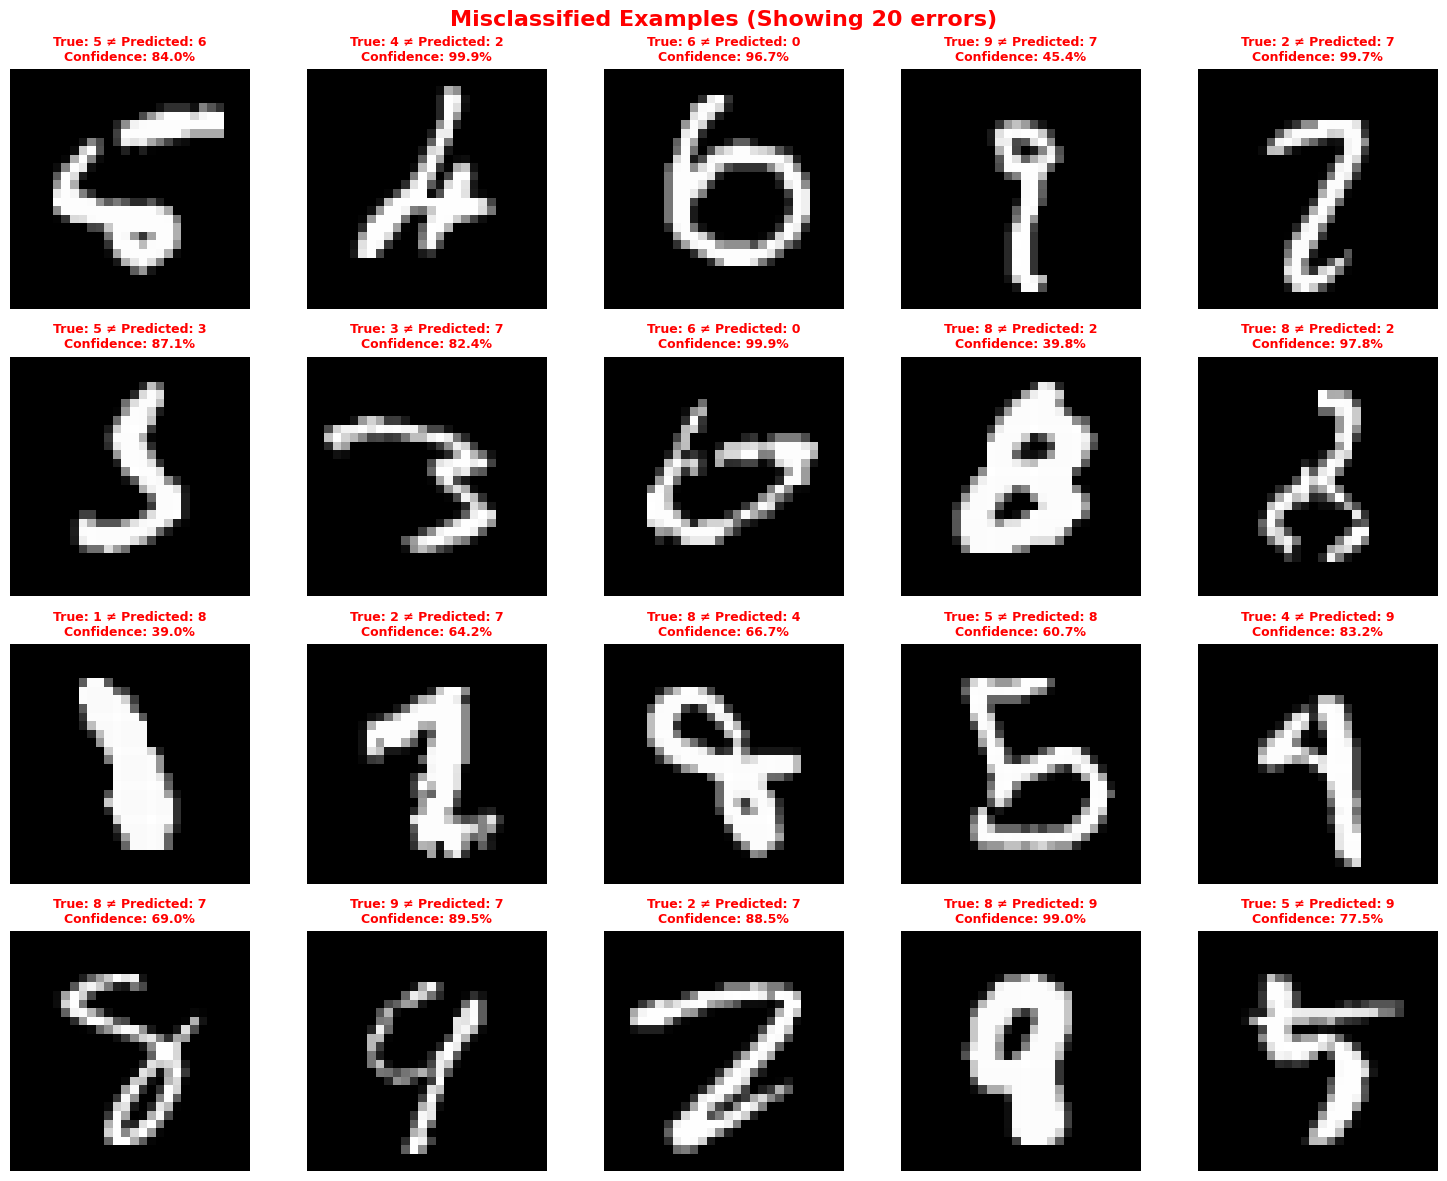


❌ Found 214 misclassified images out of 10000
Error rate: 2.14%

🔀 MOST COMMON CONFUSIONS
Top 10 most common misclassifications:
 1. Digit 5 → misclassified as 3: 14 times
 2. Digit 4 → misclassified as 9: 10 times
 3. Digit 9 → misclassified as 7: 9 times
 4. Digit 3 → misclassified as 7: 8 times
 5. Digit 5 → misclassified as 6: 8 times
 6. Digit 7 → misclassified as 2: 8 times
 7. Digit 2 → misclassified as 7: 7 times
 8. Digit 6 → misclassified as 0: 7 times
 9. Digit 8 → misclassified as 3: 7 times
10. Digit 8 → misclassified as 5: 6 times


In [14]:
# 1. Confusion Matrix
cm = confusion_matrix(y_test, predicted_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Digit Recognition', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

print("📊 How to read the Confusion Matrix:")
print("-" * 60)
print("• Rows represent TRUE labels")
print("• Columns represent PREDICTED labels")
print("• Diagonal (top-left to bottom-right) = Correct predictions")
print("• Off-diagonal values = Misclassifications")
print("• Darker blue = More occurrences")
print("-" * 60)

# 2. Classification Report
print("\n📈 DETAILED CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_test, predicted_classes, 
                          target_names=[f'Digit {i}' for i in range(10)],
                          digits=4))

print("\n📖 Metrics Explanation:")
print("-" * 60)
print("• Precision: Of all predicted X's, how many were actually X?")
print("• Recall: Of all actual X's, how many did we find?")
print("• F1-Score: Harmonic mean of precision and recall")
print("• Support: Number of actual occurrences of each digit")
print("-" * 60)

# 3. Find and visualize misclassified examples
incorrect_indices = np.where(predicted_classes != y_test)[0]
num_errors = min(20, len(incorrect_indices))

if num_errors > 0:
    fig, axes = plt.subplots(4, 5, figsize=(15, 12))
    fig.suptitle(f'Misclassified Examples (Showing {num_errors} errors)', 
                 fontsize=16, fontweight='bold', color='red')
    
    for i in range(num_errors):
        row = i // 5
        col = i % 5
        idx = incorrect_indices[i]
        
        # Display the misclassified image
        axes[row, col].imshow(X_test[idx], cmap='gray')
        
        # Title showing the error
        title = f"True: {y_test[idx]} ≠ Predicted: {predicted_classes[idx]}\n"
        title += f"Confidence: {predictions[idx][predicted_classes[idx]] * 100:.1f}%"
        axes[row, col].set_title(title, fontsize=9, color='red', fontweight='bold')
        axes[row, col].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    print(f"\n❌ Found {len(incorrect_indices)} misclassified images out of {len(y_test)}")
    print(f"Error rate: {len(incorrect_indices) / len(y_test) * 100:.2f}%")
else:
    print("\n🎉 Perfect! No errors found!")

# 4. Analyze which digit pairs are most confused
print("\n🔀 MOST COMMON CONFUSIONS")
print("=" * 60)
confusion_pairs = []
for i in range(10):
    for j in range(10):
        if i != j and cm[i][j] > 0:
            confusion_pairs.append((i, j, cm[i][j]))

confusion_pairs.sort(key=lambda x: x[2], reverse=True)

print("Top 10 most common misclassifications:")
for rank, (true_label, pred_label, count) in enumerate(confusion_pairs[:10], 1):
    print(f"{rank:2d}. Digit {true_label} → misclassified as {pred_label}: {count} times")
print("=" * 60)

## Step 12: Save the Trained Model

Great work! Now let's save our trained model so we can use it later without retraining. 💾

### Why Save the Model?

- **Reusability**: Use the model in other projects or applications
- **Deployment**: Deploy to web apps, mobile apps, or production systems
- **Time-saving**: No need to retrain every time you want to use it
- **Sharing**: Share your trained model with others

### File Formats:

1. **Keras Format (.keras)**: Recommended modern format
2. **H5 Format (.h5)**: Traditional format (still widely used)
3. **SavedModel**: TensorFlow's format (good for deployment)

Let's save our model in multiple formats:

In [15]:
# Save the model in different formats
print("💾 Saving model...\n")

# 1. Save in Keras format (Recommended)
model.save('digit_recognition_model.keras')
print("✅ Saved as 'digit_recognition_model.keras'")

# 2. Save in H5 format (Traditional)
model.save('digit_recognition_model.h5')
print("✅ Saved as 'digit_recognition_model.h5'")

# 3. Save in SavedModel format (For production/deployment)
model.save('digit_recognition_savedmodel')
print("✅ Saved as 'digit_recognition_savedmodel/' (directory)")

print("\n" + "=" * 60)
print("🎉 MODEL SAVED SUCCESSFULLY!")
print("=" * 60)

# Display file information
import os
if os.path.exists('digit_recognition_model.keras'):
    size_keras = os.path.getsize('digit_recognition_model.keras') / (1024 * 1024)
    print(f"\nModel size (.keras format): {size_keras:.2f} MB")

if os.path.exists('digit_recognition_model.h5'):
    size_h5 = os.path.getsize('digit_recognition_model.h5') / (1024 * 1024)
    print(f"Model size (.h5 format): {size_h5:.2f} MB")

print("=" * 60)

💾 Saving model...

✅ Saved as 'digit_recognition_model.keras'
✅ Saved as 'digit_recognition_model.h5'
INFO:tensorflow:Assets written to: digit_recognition_savedmodel/assets


/Users/jonas/Repositories/AI-Workshop-Lissabon/venv/lib/python3.9/site-packages/keras/src/engine/training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
INFO:tensorflow:Assets written to: digit_recognition_savedmodel/assets


✅ Saved as 'digit_recognition_savedmodel/' (directory)

🎉 MODEL SAVED SUCCESSFULLY!

Model size (.keras format): 0.44 MB
Model size (.h5 format): 1.29 MB


### Load and Use the Saved Model

Now let's demonstrate how to load the saved model and use it for predictions.

This is useful when you:
- Start a new session and want to use your trained model
- Want to deploy the model in a different application
- Share the model with teammates or collaborators

Let's load and test it:

📂 Loading saved model...

✅ Model loaded successfully!

TESTING LOADED MODEL


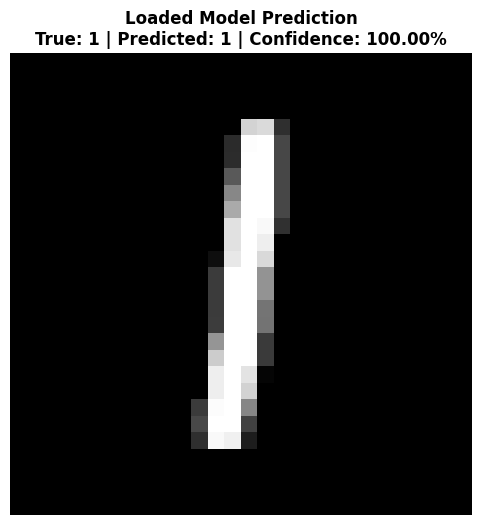


🎯 Test Results:
  Sample index: 7270
  True label: 1
  Predicted: 1
  Confidence: 100.00%
  Result: ✅ Correct!

💡 You can now use this model in other notebooks or applications!
   Just load it with: model = keras.models.load_model('digit_recognition_model.keras')


In [16]:
# Load the saved model
print("📂 Loading saved model...\n")
loaded_model = keras.models.load_model('digit_recognition_model.keras')
print("✅ Model loaded successfully!")

# Verify it works by making a prediction
print("\n" + "=" * 60)
print("TESTING LOADED MODEL")
print("=" * 60)

# Pick a random test image
test_idx = np.random.randint(0, len(X_test))
test_image = X_test_flattened[test_idx:test_idx+1]

# Make prediction with loaded model
prediction = loaded_model.predict(test_image, verbose=0)
predicted_digit = np.argmax(prediction)
confidence = prediction[0][predicted_digit]

# Display the test
plt.figure(figsize=(6, 6))
plt.imshow(X_test[test_idx], cmap='gray')
plt.title(f'Loaded Model Prediction\nTrue: {y_test[test_idx]} | Predicted: {predicted_digit} | Confidence: {confidence*100:.2f}%',
          fontsize=12, fontweight='bold')
plt.axis('off')
plt.show()

print(f"\n🎯 Test Results:")
print(f"  Sample index: {test_idx}")
print(f"  True label: {y_test[test_idx]}")
print(f"  Predicted: {predicted_digit}")
print(f"  Confidence: {confidence * 100:.2f}%")
print(f"  Result: {'✅ Correct!' if predicted_digit == y_test[test_idx] else '❌ Incorrect'}")
print("=" * 60)

print("\n💡 You can now use this model in other notebooks or applications!")
print("   Just load it with: model = keras.models.load_model('digit_recognition_model.keras')")

## 🎉 Workshop Complete! Congratulations!

You've successfully completed the Digit Recognition Workshop! Here's what you accomplished:

### 📚 Resources for Further Learning:

- **TensorFlow Documentation**: https://www.tensorflow.org/
- **Keras Guides**: https://keras.io/guides/
- **Deep Learning Book**: https://www.deeplearningbook.org/
- **Fast.ai Course**: https://www.fast.ai/
- **Kaggle Learn**: https://www.kaggle.com/learn

### 🤝 Thank You!

Thank you for participating in this workshop! Keep learning, keep experimenting, and most importantly - have fun with AI! 

Happy coding! 🎈✨